In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [ ]:
def load_and_validate_csv(path, required_cols=None):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=True)

    if required_cols:
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            print(f"[WARNING] {path} missing columns: {missing}")
    return df

In [ ]:
def eval_metrics(actual, pred):
    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred) ** 2))
    mape = np.mean(np.abs((actual - pred) / np.clip(actual, 1e-9, None))) * 100
    smape = 100 * np.mean(2 * np.abs(pred - actual) / (np.abs(actual) + np.abs(pred) + 1e-9))
    wmape = 100 * np.sum(np.abs(actual - pred)) / (np.sum(actual) + 1e-9)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape, "wMAPE": wmape}


In [ ]:
# 3. LSTM HELPERS
# =========================================================
def create_sequences(X, y, look_back=14):
    Xs, ys = [], []
    for i in range(len(X) - look_back):
        Xs.append(X[i:(i+look_back)])
        ys.append(y[i+look_back])
    return np.array(Xs), np.array(ys)

def run_lstm(daily, look_back=14):
    features = daily.drop(columns=["ds", "y"]).values
    target = daily["y"].values.reshape(-1, 1)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(features)
    y_scaled = scaler_y.fit_transform(target)

    X_seq, y_seq = create_sequences(X_scaled, y_scaled, look_back=look_back)

    split = int(0.8 * len(X_seq))
    X_train, X_test = X_seq[:split], X_seq[split:]
    y_train, y_test = y_seq[:split], y_seq[split:]

    model_lstm = Sequential([
        LSTM(64, activation="relu", return_sequences=True, input_shape=(X_seq.shape[1], X_seq.shape[2])),
        Dropout(0.2),
        LSTM(32, activation="relu"),
        Dropout(0.2),
        Dense(1)
    ])

    model_lstm.compile(optimizer="adam", loss="mse")
    model_lstm.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

    y_pred_scaled = model_lstm.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_test_rescaled = scaler_y.inverse_transform(y_test)

    # Build aligned dataframe
    dates_test = daily["ds"].iloc[-len(y_test_rescaled):].reset_index(drop=True)
    df_lstm = pd.DataFrame({"ds": dates_test, "y": y_test_rescaled.flatten(), "yhat": y_pred.flatten()})

    # Weekly
    weekly_actual = df_lstm.resample("W-MON", on="ds").sum().reset_index()
    weekly_forecast = df_lstm.resample("W-MON", on="ds").sum().reset_index()

    daily_metrics = eval_metrics(df_lstm["y"], df_lstm["yhat"])
    weekly_metrics = eval_metrics(weekly_actual["y"], weekly_forecast["yhat"])

    return df_lstm, daily_metrics, weekly_metrics

# =========================================================
# 4. MAIN PIPELINE
# =========================================================
def run_pipeline(enhanced_path, predicted_path):
    # Load
    orig = load_and_validate_csv(enhanced_path)
    pred = load_and_validate_csv(predicted_path)

    orig["event_date"] = pd.to_datetime(orig["event_date"], errors="coerce")

    # Merge event_date & quantity into predictions
    merge_cols = ["user_pseudo_id", "item_id", "event_date", "quantity"]
    exist_cols = [c for c in merge_cols if c in orig.columns]
    orig_sub = orig[exist_cols].copy()
    pred = pred.merge(orig_sub, on=["user_pseudo_id", "item_id"], how="left")

    if "quantity" not in pred.columns:
        pred["quantity"] = 1
    else:
        pred["quantity"] = pred["quantity"].fillna(1)

    # Compute expected margin
    pred["discounted_price"] = pred["original_price"] * (1 - pred["discount_percent"] / 100.0)
    pred["discount_cost"] = pred["original_price"] * (pred["discount_percent"] / 100.0) * pred["quantity"]
    pred["expected_revenue"] = pred["conversion_probability"] * (pred["discounted_price"] * pred["quantity"])
    pred["expected_margin"] = pred["expected_revenue"] - (
        pred["conversion_probability"] * pred["discount_cost"]
    )

    # Daily aggregation with regressors
    daily = (
        pred.groupby("event_date")
        .agg({
            "expected_margin": "sum",
            "discount_percent": "mean",
            "user_product_view_count": "sum",
            "user_product_purchase_count": "sum",
            "campaign_type": lambda x: x.mode()[0] if not x.mode().empty else "Unknown",
            "channel": lambda x: x.mode()[0] if not x.mode().empty else "Unknown",
        })
        .reset_index()
    )

    daily = pd.get_dummies(daily, columns=["campaign_type", "channel"], drop_first=True)
    daily.rename(columns={"event_date": "ds", "expected_margin": "y"}, inplace=True)

    # ---------------- Prophet ----------------
    model = Prophet(daily_seasonality=True, weekly_seasonality=True)
    for col in daily.columns:
        if col not in ["ds", "y"]:
            model.add_regressor(col)

    model.fit(daily)

    future = model.make_future_dataframe(periods=14)
    future = future.merge(daily.drop(columns="y"), on="ds", how="left")
    future.fillna(method="ffill", inplace=True)

    forecast = model.predict(future)
    merged = pd.merge(daily[["ds", "y"]], forecast[["ds", "yhat"]], on="ds", how="left")

    # Weekly Prophet
    weekly_actual = daily.resample("W-MON", on="ds").sum().reset_index()
    weekly_forecast = forecast[["ds", "yhat"]].resample("W-MON", on="ds").sum().reset_index()

    prophet_daily_metrics = eval_metrics(merged["y"], merged["yhat"])
    prophet_weekly_metrics = eval_metrics(weekly_actual["y"], weekly_forecast["yhat"])

    # ---------------- LSTM ----------------
    df_lstm, lstm_daily_metrics, lstm_weekly_metrics = run_lstm(daily)

    # ---------------- Forecast Plots ----------------
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    axes[0].plot(merged["ds"], merged["y"], label="Actual Margin", marker="o")
    axes[0].plot(merged["ds"], merged["yhat"], label="Prophet Forecast", marker="x")
    axes[0].plot(df_lstm["ds"], df_lstm["yhat"], label="LSTM Forecast", marker="s")
    axes[0].set_title("Daily Margin Forecast Comparison")
    axes[0].legend()

    axes[1].plot(weekly_actual["ds"], weekly_actual["y"], label="Weekly Actual", marker="o")
    axes[1].plot(weekly_forecast["ds"], weekly_forecast["yhat"], label="Prophet Weekly Forecast", marker="x")
    axes[1].set_title("Weekly Margin Forecast Comparison")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # ---------------- Managerial Insights ----------------
    # 1. Campaign Profitability
    campaign_results = (
        pred.groupby("campaign_type")
        .agg({"expected_margin": "sum", "discount_percent": "mean"})
        .reset_index()
    )
    campaign_results["Margin_per_Discount"] = campaign_results["expected_margin"] / campaign_results["discount_percent"].replace(0, np.nan)

    plt.figure(figsize=(8,5))
    plt.bar(campaign_results["campaign_type"], campaign_results["Margin_per_Discount"], color="teal")
    plt.title("Campaign Profitability (Margin per Discount)")
    plt.xticks(rotation=45)
    plt.ylabel("Margin per % Discount")
    plt.tight_layout()
    plt.show()

    # 2. Channel Effectiveness
    channel_results = (
        pred.groupby("channel")
        .agg({"expected_margin": "sum", "discount_percent": "mean"})
        .reset_index()
    )
    channel_results["Margin_per_Discount"] = channel_results["expected_margin"] / channel_results["discount_percent"].replace(0, np.nan)

    plt.figure(figsize=(8,5))
    plt.bar(channel_results["channel"], channel_results["Margin_per_Discount"], color="purple")
    plt.title("Channel Effectiveness (Margin per Discount)")
    plt.xticks(rotation=45)
    plt.ylabel("Margin per % Discount")
    plt.tight_layout()
    plt.show()

    # 3. Category Sensitivity
    segment_results = (
        pred.groupby("item_category")
        .agg({"expected_margin": "sum", "discount_percent": "mean"})
        .reset_index()
    )
    segment_results["Elasticity"] = segment_results["expected_margin"] / segment_results["discount_percent"].replace(0, np.nan)

    plt.figure(figsize=(8,5))
    plt.bar(segment_results["item_category"], segment_results["Elasticity"], color="orange")
    plt.title("Category Sensitivity (Margin Elasticity)")
    plt.xticks(rotation=45)
    plt.ylabel("Elasticity")
    plt.tight_layout()
    plt.show()

    return {
        "Prophet_Daily": prophet_daily_metrics,
        "Prophet_Weekly": prophet_weekly_metrics,
    }, campaign_results, channel_results, segment_results

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpaagvyuvy/cm1tf15l.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpaagvyuvy/f945_6we.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=50822', 'data', 'file=/tmp/tmpaagvyuvy/cm1tf15l.json', 'init=/tmp/tmpaagvyuvy/f945_6we.json', 'output', 'file=/tmp/tmpaagvyuvy/prophet_modeltajm7jve/prophet_model-20251003042326.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
04:23:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:23:27 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/tmp/ipython-input-21943168.py:110: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step


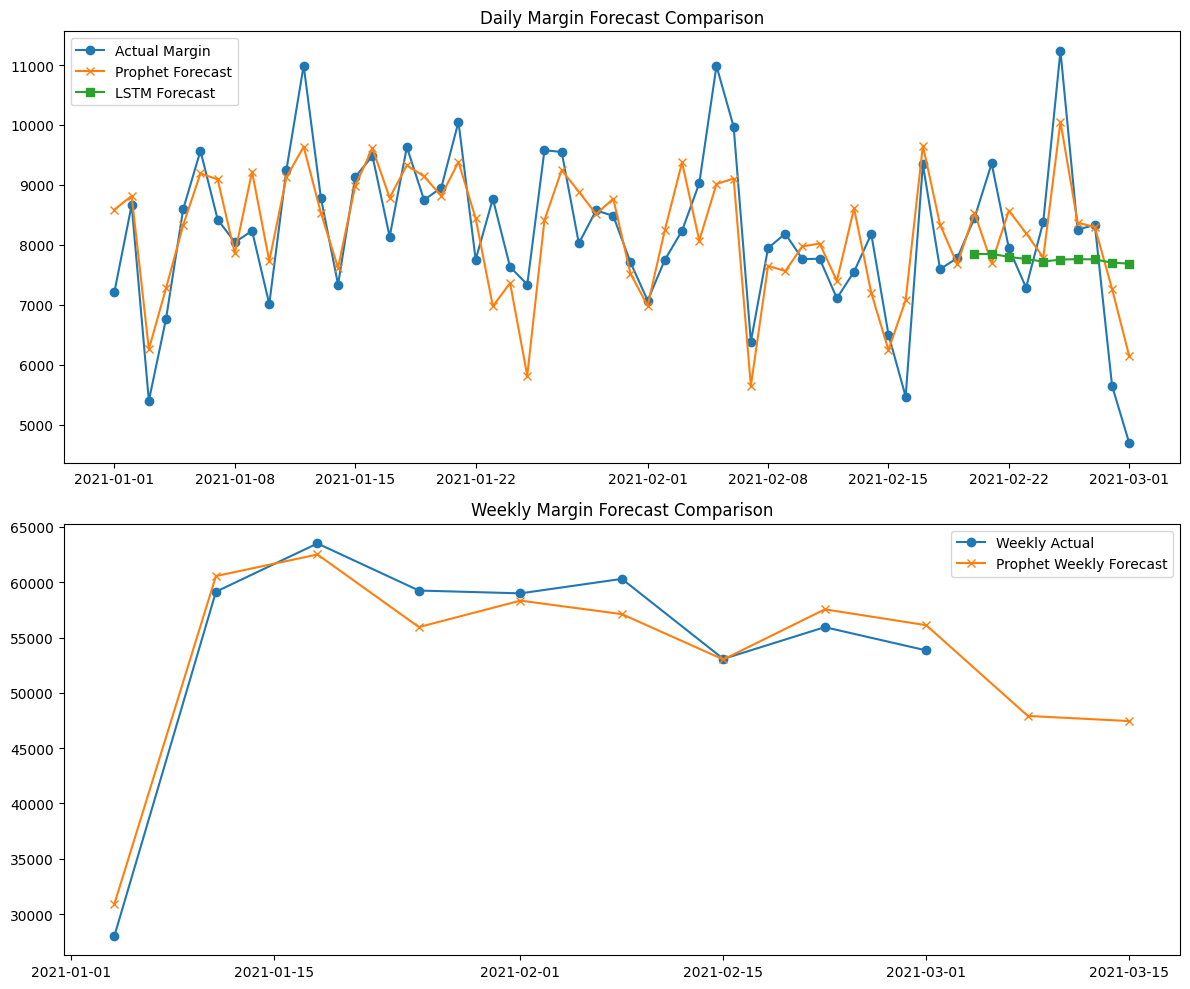

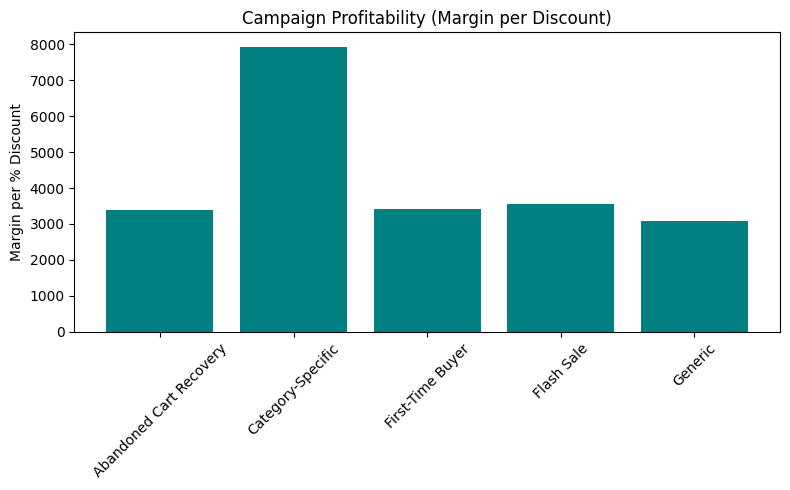

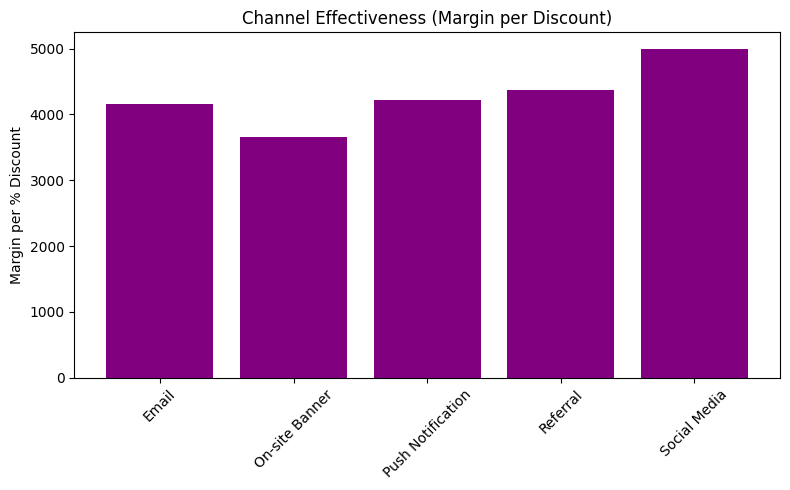

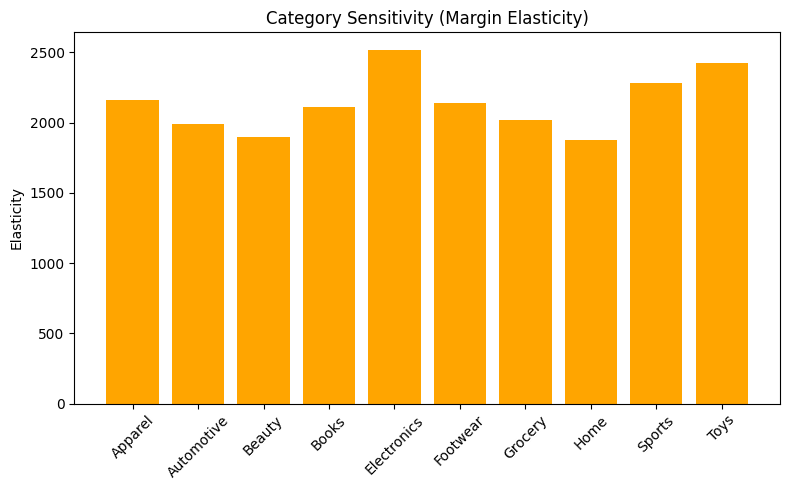


 Forecast Results Comparison:

Prophet_Daily:
   MAE  = 649.09
   RMSE = 824.84
   MAPE = 8.34
   SMAPE= 8.23
   wMAPE= 7.91

Prophet_Weekly:
   MAE  = 1821.54
   RMSE = 2124.95
   MAPE = 3.72
   SMAPE= 3.68
   wMAPE= 3.33

 Campaign Profitability (Margin per Discount):
              campaign_type  expected_margin  discount_percent  \
0  Abandoned Cart Recovery     78575.036787         23.097663   
1        Category-Specific    180657.074258         22.750069   
2         First-Time Buyer     79002.287327         23.106796   
3               Flash Sale     81056.880845         22.791817   
4                  Generic     72785.376830         23.586626   

   Margin_per_Discount  
0          3401.860866  
1          7940.946251  
2          3419.006552  
3          3556.402745  
4          3085.874868  

 Channel Effectiveness (Margin per Discount):
              channel  expected_margin  discount_percent  Margin_per_Discount
0              Email     95296.456373         22.946120      

In [ ]:
if __name__ == "__main__":
    results, campaign_results, channel_results, segment_results = run_pipeline(
        enhanced_path="enhanced_synthetic_discount_dataset.csv",
        predicted_path="predicted_conversions.csv",
    )

    print("\n Forecast Results Comparison:")
    for model_name, metrics in results.items():
        print(f"\n{model_name}:")
        for k, v in metrics.items():
            print(f"   {k:<5}= {v:.2f}")

    print("\n Campaign Profitability (Margin per Discount):\n", campaign_results)
    print("\n Channel Effectiveness (Margin per Discount):\n", channel_results)
    print("\n Category Sensitivity (Elasticity):\n", segment_results)
